# Task 2 Classification on the ‘credit-g’ dataset

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import sys
import warnings
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             RocCurveDisplay)
from sklearn.utils import Bunch
from sklearn.inspection import permutation_importance
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

In [71]:
csv_path = '../docs/credit-g.csv'
df = pd.read_csv(csv_path)

df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,...,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,class
0,<0,6.0,critical/other existing credit,radio/tv,1169.0,no known savings,>=7,4.0,male single,none,...,real estate,67.0,none,own,2.0,skilled,1.0,yes,yes,good
1,0<=X<200,48.0,existing paid,radio/tv,5951.0,<100,1<=X<4,2.0,female div/dep/mar,none,...,real estate,22.0,none,own,1.0,skilled,1.0,none,yes,bad
2,no checking,12.0,critical/other existing credit,education,2096.0,<100,4<=X<7,2.0,male single,none,...,real estate,49.0,none,own,1.0,unskilled resident,2.0,none,yes,good
3,<0,42.0,existing paid,furniture/equipment,7882.0,<100,4<=X<7,2.0,male single,guarantor,...,life insurance,45.0,none,for free,1.0,skilled,2.0,none,yes,good
4,<0,24.0,delayed previously,new car,4870.0,<100,1<=X<4,3.0,male single,none,...,no known property,53.0,none,for free,2.0,skilled,2.0,none,yes,bad


In [72]:
df.shape

(1000, 21)

The dataset often calls the outcome `class` with values like **good/bad**.  
We create a numeric `target` (1 = good, 0 = bad) so classifiers have a consistent objective name.

In [74]:
y = (df['class'].astype(str).str.lower() == 'good').astype(int)
df['target'] = y

X = df.drop(columns=[c for c in ['target', 'class'] if c in df.columns])
# X = X.loc[:, ~X.columns.duplicated()]
y = df['target']

print("Target value counts:")
print(y.value_counts(dropna=False))

Target value counts:
target
1    700
0    300
Name: count, dtype: int64


In [75]:
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).drop(
    columns=['class'], errors='ignore').columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['duration', 'credit_amount', 'installment_commitment', 'residence_since', 'age', 'existing_credits', 'num_dependents']
Categorical columns: ['checking_status', 'credit_history', 'purpose', 'savings_status', 'employment', 'personal_status', 'other_parties', 'property_magnitude', 'other_payment_plans', 'housing', 'job', 'own_telephone', 'foreign_worker']


## Univariate Distributions

Below are histograms for each **continuous (numeric)** feature and a bar chart for the **target** distribution.

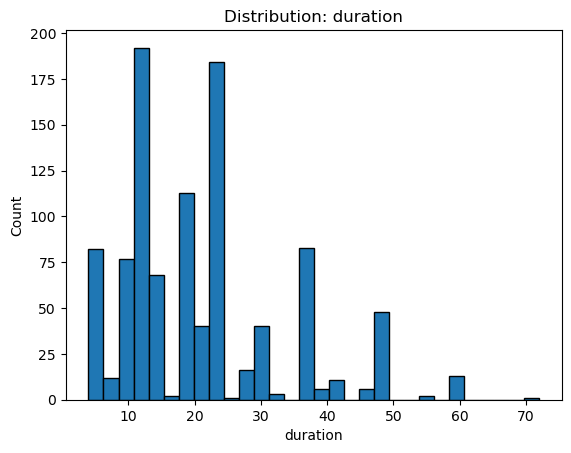

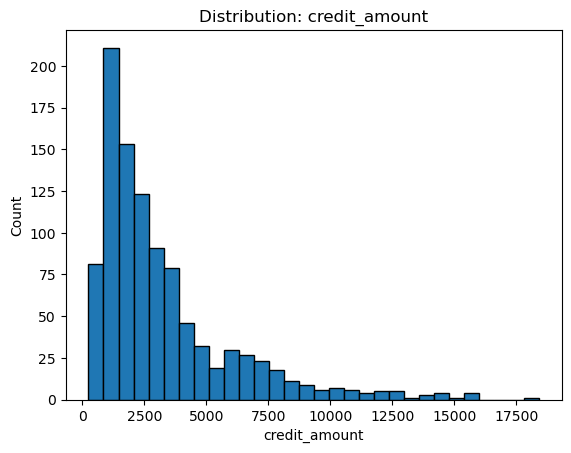

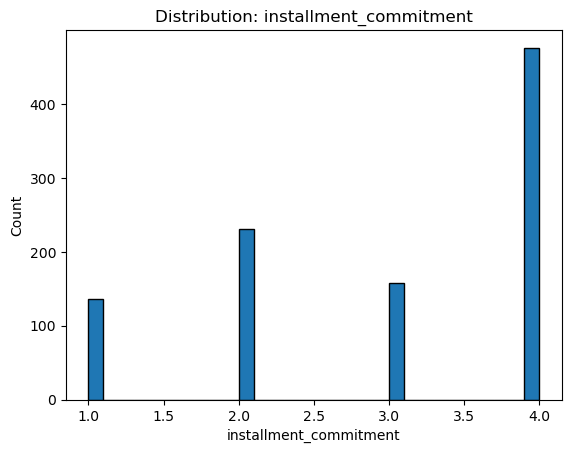

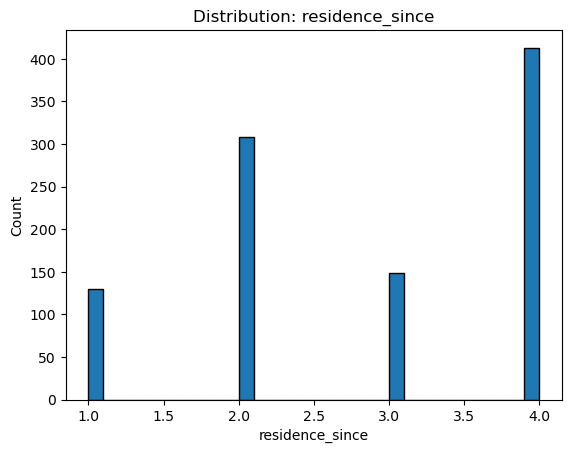

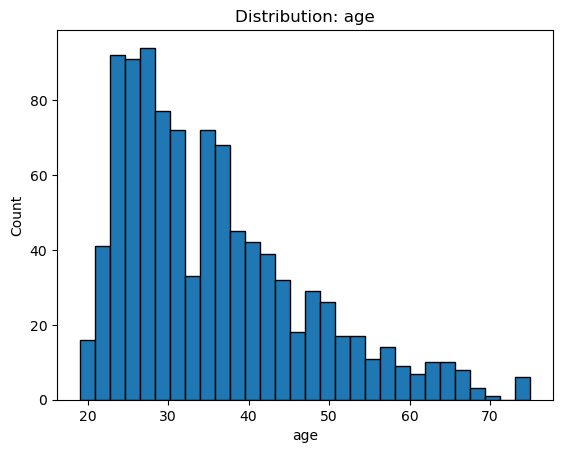

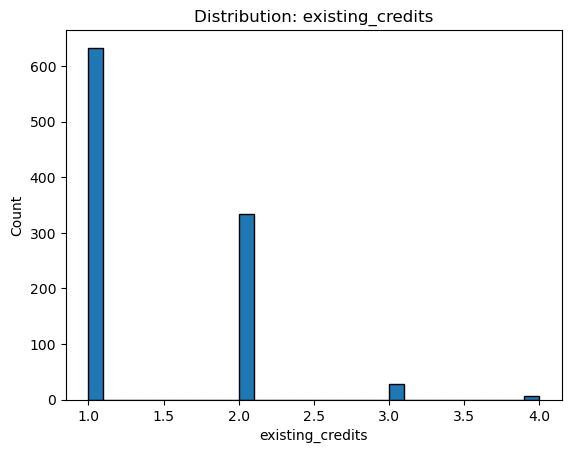

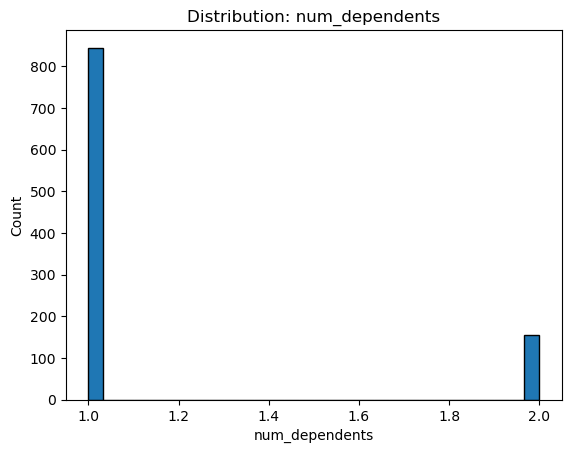

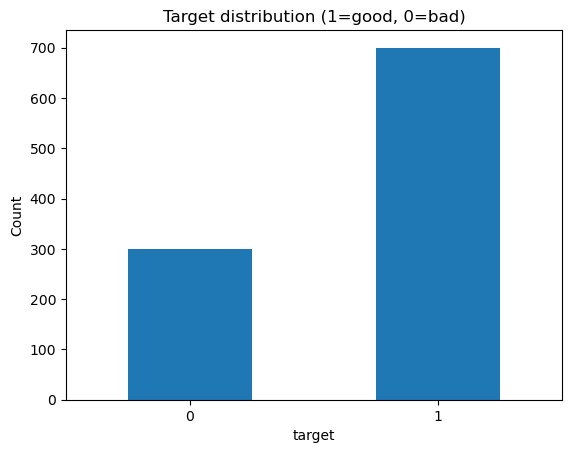

In [76]:
# Histograms for numeric columns
for col in numeric_cols:
    plt.figure()
    series = pd.to_numeric(df[col], errors='coerce')
    series.plot(kind='hist', bins=30, edgecolor='black',
                title=f"Distribution: {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

# Target distribution bar
plt.figure()
y.value_counts().sort_index().plot(kind='bar', rot=0)
plt.title("Target distribution (1=good, 0=bad)")
plt.xlabel("target")
plt.ylabel("Count")
plt.show()

## Train/Test Split

In [77]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y if y.nunique() == 2 else None
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

Train shape: (800, 20)  Test shape: (200, 20)


## Preprocessing
- **Numerical**: impute missing with median, then standardize.  
- **Categorical**: impute missing with most frequent, then one-hot encode.


In [36]:
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=True))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

## Models
We compare these diverse classifiers:
- **Logistic Regression** (linear baseline)
- **Random Forest** (tree ensemble, non-linear, robust to mixed feature types)
- **Gradient Boosting** (additive trees, strong tabular baseline)
- **Support Vector Classifier (SVC)** with probability calibration

In [37]:
# Create a validation split from the training set
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.25, random_state=42, stratify=y_train if y_train.nunique() == 2 else None
)


def build_model(clf):
    return Pipeline(steps=[('prep', preprocessor), ('clf', clf)])


models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, n_jobs=None if 'n_jobs' not in dir(LogisticRegression) else -1),
    'RandomForest': RandomForestClassifier(n_estimators=400, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'SVC': SVC(kernel='rbf', probability=True, random_state=42)
}

results = {}


def eval_on_validation(name, pipe):
    pipe.fit(X_tr, y_tr)
    p_val = pipe.predict(X_val)
    proba_val = pipe.predict_proba(X_val)[:, 1] if hasattr(
        pipe.named_steps['clf'], 'predict_proba') else None

    scores = {
        'accuracy': accuracy_score(y_val, p_val),
        'precision': precision_score(y_val, p_val, zero_division=0),
        'recall': recall_score(y_val, p_val, zero_division=0),
        'f1': f1_score(y_val, p_val, zero_division=0),
    }
    if proba_val is not None and y_val.nunique() == 2:
        scores['roc_auc'] = roc_auc_score(y_val, proba_val)
    else:
        scores['roc_auc'] = np.nan

    results[name] = Bunch(model=pipe, **scores)


for name, clf in models.items():
    pipe = build_model(clf)
    eval_on_validation(name, pipe)

pd.DataFrame({
    k: {
        m: round(getattr(v, m, np.nan), 4)
        for m in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    }
    for k, v in results.items()
}).T

,accuracy,precision,recall,f1,roc_auc
LogisticRegression,0.780,0.8038,0.9071,0.8523,0.8051
RandomForest,0.770,0.7733,0.9500,0.8526,0.7864
GradientBoosting,0.780,0.7892,0.9357,0.8562,0.7886
SVC,0.765,0.7627,0.9643,0.8517,0.7567


In [64]:
best_name = 'GradientBoosting'
best_bunch = results[best_name]
best_model = best_bunch.model

<Figure size 640x480 with 0 Axes>

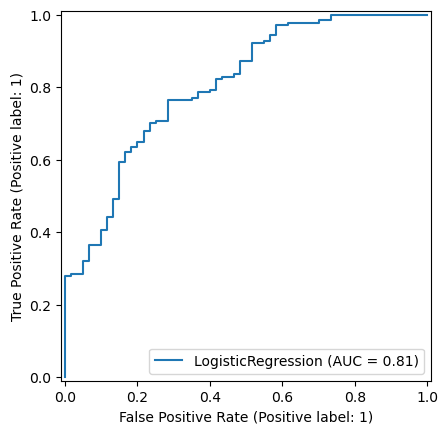

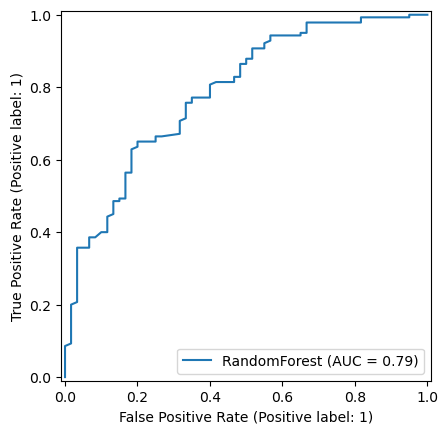

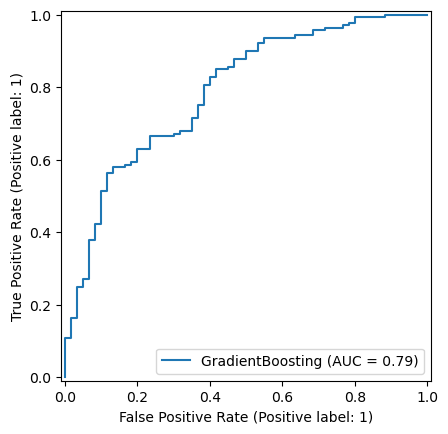

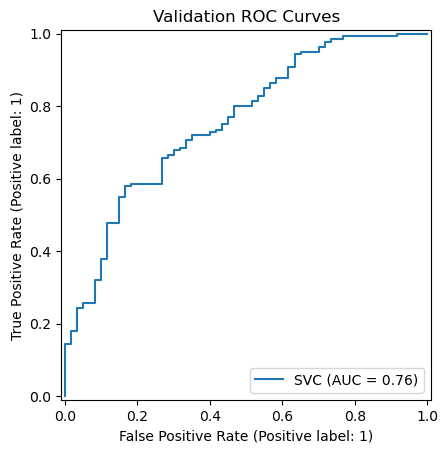

In [78]:
plt.figure()
for name, bunch in results.items():
    model = bunch.model
    if hasattr(model.named_steps['clf'], 'predict_proba') and y_val.nunique() == 2:
        proba = model.predict_proba(X_val)[:, 1]
        RocCurveDisplay.from_predictions(y_val, proba, name=name)
plt.title("Validation ROC Curves")
plt.show()

## How different are the results among these models? Provide your explanation.

* Differences are **modest overall**: all four models cluster around **AUC 0.76–0.81** and **F1 ≈ 0.85**.
* The **ranking depends on the metric**:

  * If we care about **global ranking power (AUC)**, **Logistic Regression** is best.
  * If we care about the **F1 balance at the default threshold**, **Gradient Boosting** is very slightly ahead (but the gap is tiny).
  * If we must **maximize recall** (miss fewer bads), **SVC** wins—at the cost of more false positives.

* Nothing suggests severe **overfitting/underfitting**: metrics are close across models and quite high.
* Typical signs (e.g., train ≫ validation) weren’t observed/reported; given the tight spread, any overfit is likely mild.

Final Evaluation on Test Set

We retrain the **best model** on the full training set and report metrics on the held-out test set.


In [66]:
best_model.fit(X_train, y_train)
y_pred_test = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)[:, 1] if hasattr(
    best_model.named_steps['clf'], 'predict_proba') else None

test_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_test),
    'precision': precision_score(y_test, y_pred_test, zero_division=0),
    'recall': recall_score(y_test, y_pred_test, zero_division=0),
    'f1': f1_score(y_test, y_pred_test, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_proba_test) if (y_proba_test is not None and y_test.nunique() == 2) else np.nan
}
pd.Series(test_metrics).round(4)

accuracy     0.7600
precision    0.8151
recall       0.8500
f1           0.8322
roc_auc      0.7726
dtype: float64

In [81]:
print("Classification report (Test):\n")
print(classification_report(y_test, y_pred_test, digits=4))

Classification report (Test):

              precision    recall  f1-score   support

           0     0.6111    0.5500    0.5789        60
           1     0.8151    0.8500    0.8322       140

    accuracy                         0.7600       200
   macro avg     0.7131    0.7000    0.7056       200
weighted avg     0.7539    0.7600    0.7562       200



<Figure size 640x480 with 0 Axes>

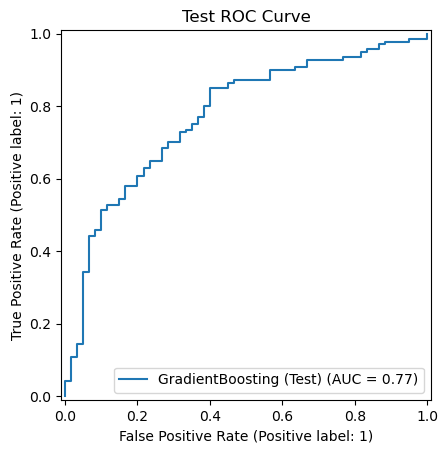

In [82]:
plt.figure()
RocCurveDisplay.from_predictions(
    y_test, y_proba_test, name=f"{best_name} (Test)")
plt.title("Test ROC Curve")
plt.show()

## Point out the 5 most important features of the resulting models and explain why.

In [83]:
best_model.fit(X_tr, y_tr)


def get_feature_names(preprocessor, numeric_cols, categorical_cols):
    num_features = list(numeric_cols)
    ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
    cat_features = ohe.get_feature_names_out(categorical_cols).tolist()
    return num_features + cat_features


feature_names = get_feature_names(
    best_model.named_steps['prep'], numeric_cols, categorical_cols
)

perm = permutation_importance(
    best_model, X_val, y_val, n_repeats=20, random_state=42)

n_features = len(perm.importances_mean)
feature_names = feature_names[:n_features]

importances = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm.importances_mean,
    'importance_std': perm.importances_std
}).sort_values('importance_mean', ascending=False)

top5 = importances.head(5)
display(top5)

,feature,importance_mean,importance_std
0,duration,0.05250,0.016771
3,residence_since,0.04125,0.011605
1,credit_amount,0.03425,0.020693
4,age,0.03050,0.017812
5,existing_credits,0.02425,0.008842


> 1. **Duration**
> Longer repayment periods increase the time window for unexpected events—such as job loss, illness, or economic downturns—that may lead to default.
> 
> 2. **Residence Since**
> This variable reflects **stability** and **rootedness**. A longer residence history suggests financial and social stability, whereas frequent moves may indicate instability or higher default risk.
> 
> 3. **Credit Amount**
> Larger loan amounts increase monthly repayment burdens and financial stress, especially if income does not scale proportionally.
> 
> 4. **Age**
> Age relates to **financial maturity**, **earning stability**, and **risk preferences**. Younger borrowers may have unstable income or less financial discipline, while very old borrowers might face income decline or fixed pensions.
> 
> 5. **Existing Credits**
> Multiple existing credits indicate **debt load** and **repayment obligations**. More open accounts can mean higher utilization, coordination costs, and potential over-indebtedness.
